# Comparing resolvers under position uncertainty

MVP and VO ship with the library and both clear a textbook 90° crossing. This notebook asks a
narrower question — **how does each hold up as the crossing gets shallow and the position fix gets
worse?** — and answers it for a third resolver written here in the notebook, to show what comparing
your own against the references costs: one class, one dict entry, nothing else.

Shallow crossings are the interesting end. Two aircraft converging at 2° close on each other at a
fraction of their airspeed, so the geometry evolves slowly, the predicted miss distance is
ill-conditioned, and a resolver has a long time to make a small mistake repeatedly. The papers this
project reproduces sweep from 2° for that reason.

Everything is held fixed except three things:

| | | |
|---|---|---|
| **swept** | crossing angle `dpsi` | 2°, 5°, 10°, 30° |
| **swept** | position accuracy `pos_ci95` | 10 m, 30 m (95% radial) |
| **swept** | resolver | `MVP(1.05)`, `VO(1.05)`, `CloseRangeAvoid()` — written below |
| held | airframe | `M600`, both aircraft |
| held | speed | 10 m/s, both aircraft |
| held | miss distance `dcpa` | 0 m — head-for-head-on, the hardest case at each angle |
| held | spawn `tlos` | 180 s to protected-zone entry |
| held | protected zone `rpz` / lookahead | 50 m / 120 s |
| held | velocity accuracy `vel_ci95` | 1 m/s |
| held | detection / recovery | `StateBased` / `PastCPA` |

and two things are reported: **P(LoS)**, how often separation was lost, and the **median achieved
minimum separation**, how much room was left when it was not.

**The notebook runs the whole thing first, then takes it apart.** The experiment is one call, one
table and one figure; everything after that is those same twenty-four numbers opened up a layer at a
time — one condition, the record inside a condition, and one encounter.

> **On the VO numbers.** This library's `VO` is a re-derivation, not a port, and it has not been
> validated against a reference implementation. Read its results as a measurement of *this*
> implementation rather than of velocity-obstacle methods in general. `CloseRangeAvoid` is a toy,
> included to be compared against rather than proposed.

In [14]:
%matplotlib inline
import dataclasses
import math
import tempfile
from collections.abc import Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    MC,
    MVP,
    VO,
    Fixed,
    GnssNavigation,
    M600,
    Methods,
    PastCPA,
    StateBased,
    Sweep,
    run_experiment,
)
from opencdarr.config import load_config
from opencdarr.cr.base import ConflictResolver
from opencdarr.fleet import Agent, run_fleet
from opencdarr.kinematics import MotionCommand
from opencdarr.relative import relative_enu, velocity_enu
from opencdarr.rng import generator, root_seed_sequence, spawn
from opencdarr.scenario import sample_pairwise
from opencdarr.state import AircraftState
from opencdarr.viz import extract_tracks

BLUE, RED, ORANGE, GREY = "#1f77b4", "#d62728", "#ff7f0e", "0.45"

ANGLES = [2.0, 5.0, 10.0, 30.0]
NOISE = [10.0, 30.0]
MARGIN = 1.05
SPEED = 10.0            # m/s, both aircraft
TLOS = 180.0            # s to protected-zone entry
RPZ = 50.0              # m
SEED = 0

In [15]:
class CloseRangeAvoid(ConflictResolver):
    # Hold course until an intruder is within `trigger` metres, then turn 90 deg right.

    cache_id = "close-range-avoid/v1"   # owns its own cache identity, see below

    def __init__(self, trigger: float = 70.0) -> None:
        self.trigger = trigger

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        v_east, v_north = velocity_enu(own)          # own's current ground velocity
        nearest = min((relative_enu(own, i).dist for i in intruders), default=float("inf"))
        if nearest <= self.trigger:
            return MotionCommand(target_velocity=(v_north, -v_east))  # 90 deg right, same speed
        return MotionCommand(target_velocity=(v_east, v_north))       # else: unchanged

# register your CR algorithm here
RESOLVERS = {"MVP": MVP(MARGIN), "VO": VO(MARGIN), "MINE": CloseRangeAvoid()}

In [16]:
# the stack every condition runs, minus the resolver, which is swept
methods = Methods(
    detector=StateBased(),
    resolver=RESOLVERS["MVP"],   # the default; the resolver axis overrides it per condition
    recovery=PastCPA(),
    navigation=GnssNavigation(),
    perf=M600,
)

base = dataclasses.replace(load_config("../../configs/pairwise.yaml"), n_encounters=500)
print(f"rpz {base.conflict.rpz:.0f} m   lookahead {base.conflict.t_lookahead:.0f} s"
      f"   dt {base.simulation.dt:.1f} s   broadcast {base.simulation.broadcast_interval:.1f} s"
      f"   airframe {base.scenario.aircraft_type}")

# The handbook page for this notebook publishes these figures. They are written from here rather
# than redrawn by a separate script, so the page and the notebook cannot disagree about a number.
SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"


def publish(fig, name: str) -> None:
    # save into the handbook's assets, when the site repo sits alongside this one
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)

rpz 50 m   lookahead 120 s   dt 1.0 s   broadcast 1.0 s   airframe M600


## The third resolver

`CloseRangeAvoid`, in the cell above, is the whole contribution surface in fifteen lines: subclass
`ConflictResolver`, implement `resolve`, return a `MotionCommand`. Hold course until an intruder is
within 70 m, then turn 90° right.

It is deliberately naive — it ignores `rpz`, the closing speed, and the `preferred` velocity it is
handed — because the point is to show what it costs to stand your own algorithm beside the
references, not to propose it as a good one.

The `cache_id` class attribute is the one piece of housekeeping. `cache=True` has to key each
resolver distinctly, and by default `identity()` does that by hashing the class's own source, so an
edit to `resolve` invalidates the entry. Declaring `cache_id` instead means *you* own that promise
and must bump it when the logic changes — worth it for a class defined in a notebook, where the
source is less stable than a file's.

## The experiment

Twenty-four conditions: four angles × two accuracies × three resolvers, 500 encounters each. Each
condition is an independent seeded fan-out from the same root, so two of them differ by their
declared levels and nothing else — that is what makes a sweep a comparison rather than a set of
runs.

`base_config` supplies the parameters no axis mentions; anything declared as `Fixed` or `Sweep`
overrides it. Two details worth noticing in the declaration:

- **`dpsi` is declared first** because the first `Sweep` becomes the x-axis, and the rest become
  one line each.
- **the resolver axis sweeps names, not objects** — `build=` maps a level onto the value the run
  needs, so the table reads `MVP` / `VO` / `MINE` while the run receives the instances.

`cache=True` stores one entry per condition, keyed on the config, the component identities and the
library code fingerprint, so re-running this cell is instant and extending the sweep only runs the
new cells.

In [2]:
sweep = run_experiment(
    {"dpsi": Sweep(ANGLES),
     "resolver": Sweep(list(RESOLVERS), build=RESOLVERS.__getitem__, name="resolver"),
     "pos_ci95": Sweep(NOISE),
     "vel_ci95": Fixed(1.0), "dcpa": Fixed(0.0), "tlos": Fixed(TLOS), "speed": Fixed(SPEED)},
    methods=methods,
    backend=MC(n_encounters=500),
    base_config=base,
    seed=SEED,
    cache=True,
    n_jobs=4,
)

rows = sweep.records()
sweep.frame()[["dpsi", "resolver", "pos_ci95", "p_los", "p_los_lo", "p_los_hi",
               "median_min_sep", "n_los", "detection_rate"]].round(4)

,dpsi,resolver,pos_ci95,p_los,p_los_lo,p_los_hi,median_min_sep,n_los,detection_rate
0,2.0,MVP,10.0,0.050,0.0341,0.0728,53.3005,25,0.972
1,2.0,MVP,30.0,0.046,0.0308,0.0681,57.8426,23,1.000
2,2.0,VO,10.0,0.794,0.7564,0.8271,23.6029,397,0.998
3,2.0,VO,30.0,0.970,0.9511,0.9817,19.7395,485,1.000
4,2.0,MINE,10.0,0.474,0.4306,0.5178,50.1959,237,1.000
5,2.0,MINE,30.0,0.894,0.8639,0.9180,44.1463,447,1.000
6,5.0,MVP,10.0,0.038,0.0245,0.0586,58.1012,19,0.802
7,5.0,MVP,30.0,0.032,0.0198,0.0513,64.8536,16,0.946
8,5.0,VO,10.0,0.248,0.2122,0.2877,58.5307,124,0.806
9,5.0,VO,30.0,0.454,0.4109,0.4978,53.0924,227,0.966


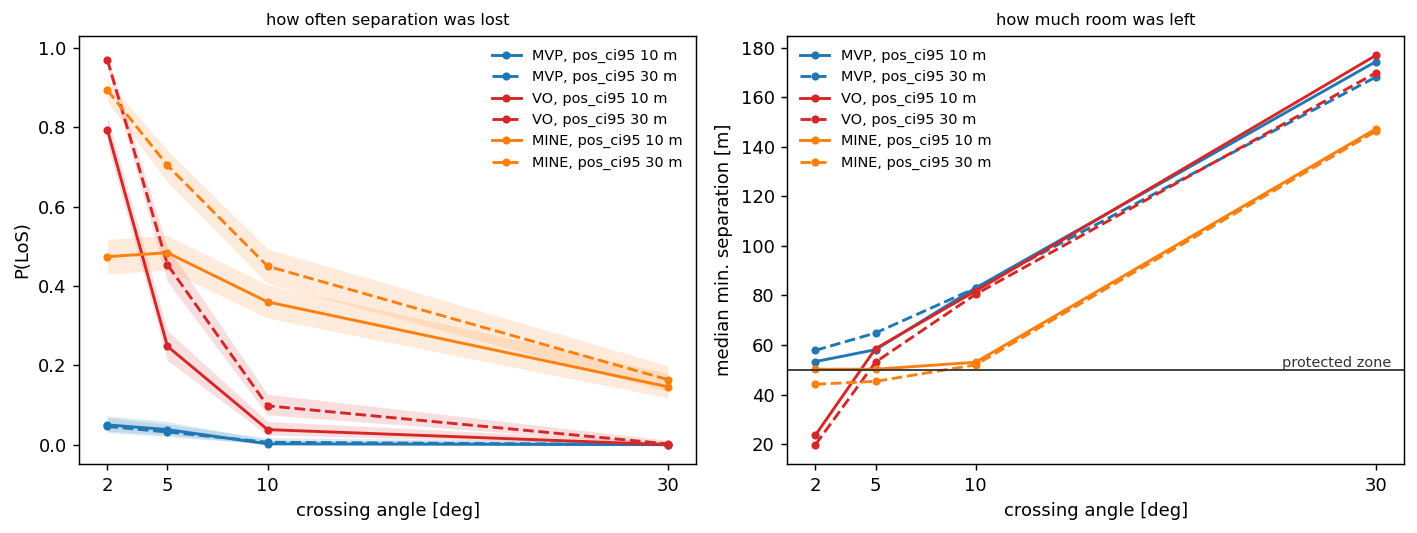

In [3]:
def response_curve(ax, metric: str, *, band: bool = False) -> None:
    for name, colour in (("MVP", BLUE), ("VO", RED), ("MINE", ORANGE)):
        for pos, style in zip(NOISE, ("-", "--")):
            group = sorted((r for r in rows if r["resolver"] == name and r["pos_ci95"] == pos),
                           key=lambda r: r["dpsi"])
            xs = [r["dpsi"] for r in group]
            ax.plot(xs, [r[metric] for r in group], style, marker="o", ms=3.5, lw=1.6,
                    color=colour, label=f"{name}, pos_ci95 {pos:.0f} m")
            if band:
                ax.fill_between(xs, [r[f"{metric}_lo"] for r in group],
                                [r[f"{metric}_hi"] for r in group],
                                alpha=0.15, color=colour, lw=0)
    ax.set_xlabel("crossing angle [deg]")
    ax.set_xticks(ANGLES)
    ax.legend(frameon=False, fontsize=8, loc="best")


fig, (ax_p, ax_m) = plt.subplots(1, 2, figsize=(11.0, 4.2))

response_curve(ax_p, "p_los", band=True)
ax_p.set_ylabel("P(LoS)")
ax_p.set_title("how often separation was lost", fontsize=9)

response_curve(ax_m, "median_min_sep")
ax_m.axhline(RPZ, color="0.2", lw=1.0)
ax_m.annotate("protected zone", (0.98, RPZ), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color="0.2")
ax_m.set_ylabel("median min. separation [m]")
ax_m.set_title("how much room was left", fontsize=9)
fig.tight_layout()
publish(fig, "exp-response-curves")

Both metrics against crossing angle, 500 encounters per point. Solid lines are a 10 m position fix,
dashed 30 m; the shaded bands on the left are 95% Wilson intervals. The right panel carries no
band — a Wilson interval is for a binomial rate and a median is not one, though there is still a
way to put an interval on it, further down.

**The two library resolvers find shallow crossings hardest**, which is the expected shape and
matches what the papers report. Both are comfortable by 30°.

**`CloseRangeAvoid` does not have that shape.** It declines far more slowly — 0.47, 0.48, 0.36,
0.15 across the axis — and is still losing separation in 15% of encounters at 30°, where the other
two are at zero. That is the signature of a rule with no geometry in it: a fixed 70 m trigger does
not know that a wider crossing gives it more room and more closing speed to work with, so it reacts
the same way everywhere and the geometry never rescues it.

**Only one of the three is indifferent to the position fix.** MVP's two curves lie on top of each
other — 0.050 against 0.046 at 2°, 0.038 against 0.032 at 5°, intervals overlapping everywhere, so
tripling the position error changed nothing measurable. VO's separate cleanly (0.248 to 0.454 at
5°), and so do `CloseRangeAvoid`'s (0.474 to 0.894 at 2°).

**The second metric is not a restatement of the first.** Four places it says something P(LoS)
cannot:

- *At 30°, where P(LoS) has bottomed out.* MVP and VO are both at zero, so the rate cannot tell
  "equivalent" from "both below what 500 encounters resolves". The medians can, and they say
  equivalent: 174 m against 177 m at a 10 m fix, 168 m against 170 m at 30 m.
- *At 2°, where P(LoS) looks comfortable.* MVP reports 0.05, which reads as a 95% success rate. Its
  median is 53 m against a 50 m protected zone.
- *At 10°, where two resolvers disagree.* MVP and VO's medians nearly coincide — 83.0 m against
  81.8 m — while P(LoS) reads 0.002 against 0.038, a nineteenfold difference. The median describes
  the bulk of the distribution and P(LoS) describes its tail, and a resolver can do well on one
  while doing badly on the other.
- *Wherever `CloseRangeAvoid` runs.* Its median is **50.2 m at 2°, 50.2 m at 5° and 53.0 m at 10°**
  — on the 50 m protected zone, or within three metres of it, across a fifteenfold change in closing
  speed. A resolver that starts avoiding at a fixed range ends up parked at that range, and the
  median says so in one number where three P(LoS) values would not.

**One column gives the mechanism away.** `detection_rate` is ~1.0 for `CloseRangeAvoid` everywhere,
while MVP's falls to 0.40 at 30°. That column counts encounters the true-state detector ever
flagged: MVP opens the predicted miss past `rpz` before the look-ahead horizon reaches the
encounter, so the detector never fires. `CloseRangeAvoid` never pre-empts — it waits for 70 m — so
every encounter stays a conflict all the way in. This is why `detection_rate` is a diagnostic and
never a denominator: it moves with the resolver's behaviour.

That is one pairwise experiment: a declaration, a backend, a seed, two response surfaces. The rest
of this notebook is the same twenty-four numbers, opened up.

## Decomposing it

A sweep is a stack of nested things, and every layer is reachable on its own. Working down:

| layer | what it is | how to get it |
|---|---|---|
| **experiment** | 24 conditions | `run_experiment(...)` — above |
| **condition** | 500 encounters at one set of levels | all-`Fixed` declaration, or `sweep.cell(...)` |
| **record** | one achieved separation per encounter | `result.min_seps` |
| **encounter** | one geometry, one run, one outcome | `sample_pairwise` + `run_fleet` |

### One condition

Declaring every parameter as `Fixed` gives a single row. It is not a different code path from the
sweep — it is the sweep with nothing to cross-product — so it reproduces the corresponding cell
exactly, which the assertion below pins.

In [4]:
one_cell = run_experiment(
    {"dpsi": Fixed(2.0), "pos_ci95": Fixed(10.0), "vel_ci95": Fixed(1.0),
     "dcpa": Fixed(0.0), "tlos": Fixed(TLOS), "speed": Fixed(SPEED)},
    methods=methods,             # resolver=MVP, as declared in the setup cell
    backend=MC(n_encounters=500),
    base_config=base,
    seed=SEED,
)

row = one_cell.records()[0]
print(f"P(LoS)          {row['p_los']:.3f}  95% CI [{row['p_los_lo']:.3f}, {row['p_los_hi']:.3f}]")
print(f"median min_sep  {row['median_min_sep']:.2f} m")
print(f"counts          {row['n_los']} LoS in {row['n_encounters']} encounters")
print(f"detection_rate  {row['detection_rate']:.3f}")

swept_cell = sweep.cell(dpsi=2.0, resolver="MVP", pos_ci95=10.0)
assert (row["p_los"], row["median_min_sep"]) == (swept_cell.p_los, swept_cell.median_min_sep)
print("\nidentical to the sweep's dpsi=2, MVP, pos_ci95=10 cell")

P(LoS)          0.050  95% CI [0.034, 0.073]
median min_sep  53.30 m
counts          25 LoS in 500 encounters
detection_rate  0.972

identical to the sweep's dpsi=2, MVP, pos_ci95=10 cell


`navigation=GnssNavigation()` is load-bearing, not decoration. `pos_ci95` is a number stamped on
every aircraft state, and a navigation model is what *draws an error from it*; without one the
field is carried through the whole run and never read, so a noise sweep would return identical
cells and report that accuracy does not affect safety. `run_experiment` refuses that declaration
rather than running it — try deleting the `navigation=` line in the setup cell to see the error.

`detection_rate` is a diagnostic, not a denominator. Below 1 means the true-state detector never
flagged some of these encounters — here because they spawn at `tlos = 180 s`, outside the 120 s
lookahead, and the resolver often grows the predicted miss past `rpz` before the horizon catches
them. P(LoS) divides by the encounter count precisely so that a resolver cannot shrink its own
denominator by succeeding.

### The record inside a condition

`cell()` hands back the raw estimator result, which carries one achieved minimum separation per
encounter. The two reported metrics are reductions of it, and anything else you want to ask of the
same 500 runs is a read rather than another simulation.

In [5]:
result = one_cell.cell()
seps = np.array(result.min_seps)

print(f"encounters       {len(seps)}")
print(f"P(min_sep < 50)  {(seps < 50).mean():.3f}   <- this is p_los, by definition")
print(f"P(min_sep < 25)  {(seps < 25).mean():.3f}")
print(f"P(min_sep < 10)  {(seps < 10).mean():.3f}")
print(f"quartiles        {np.percentile(seps, [25, 50, 75]).round(1)} m")

encounters       500
P(min_sep < 50)  0.050   <- this is p_los, by definition
P(min_sep < 25)  0.000
P(min_sep < 10)  0.000
quartiles        [51.8 53.3 55. ] m


Worth pausing on those quartiles. MVP at 2° puts the middle half of its encounters between 51.8 m
and 55.0 m — a spread of three metres, sitting directly on top of a 50 m protected zone. This is
not a resolver that is usually comfortable and occasionally unlucky; it is one that steers to the
boundary every time and crosses it when the noise goes the wrong way. The 5% failure rate and the
tight distribution are the same fact seen twice.

The breaches are shallow, too: `P(min_sep < 25)` is zero, so none of the 25 losses came close to a
collision. Whether that is reassuring depends on what the protected zone is for — but it is a
distinction the LoS flag throws away, and one you would have to re-run to recover if the record
were not kept.

### An interval on the median

Back to the response curves for a moment. MVP's median *rises* with worse position accuracy at the
shallow end — 53.3 m to 57.8 m at 2°, 58.1 to 64.9 at 5° — while its P(LoS) does not move. More
noise, more room.

The table quotes no interval on the median, so on the face of it there is no way to say whether
that is real or sampling noise. But the per-encounter record is right there, and a median has a
bootstrap interval for the asking — no new simulation, just resampling the 500 values that already
exist.

In [6]:
def median_ci(seps, *, n_boot: int = 5000, seed: int = 1) -> tuple[float, float]:
    g = np.random.default_rng(seed)
    draws = g.choice(seps, size=(n_boot, len(seps)), replace=True)
    return tuple(np.percentile(np.median(draws, axis=1), [2.5, 97.5]))


print(f"{'dpsi':>5} {'pos_ci95':>9} {'median [m]':>11} {'95% bootstrap CI':>22}")
for dpsi in (2.0, 5.0):
    for pos in NOISE:
        seps = np.array(sweep.cell(dpsi=dpsi, resolver="MVP", pos_ci95=pos).min_seps)
        lo, hi = median_ci(seps)
        print(f"{dpsi:>5.0f} {pos:>9.0f} {np.median(seps):>11.2f}   [{lo:>7.2f}, {hi:>7.2f}]")

 dpsi  pos_ci95  median [m]       95% bootstrap CI
    2        10       53.30   [  53.12,   53.58]
    2        30       57.84   [  57.39,   58.21]
    5        10       58.10   [  57.52,   58.81]
    5        30       64.85   [  63.77,   66.22]


The intervals are disjoint at both angles, so the rise is not sampling noise: at this seed and this
sample size, giving MVP a worse position fix really does leave it further from the intruder.

There is a known mechanism that produces exactly this. A resolver re-commanding from its own noisy
fix re-aims slightly wrong each tick, and that random walk does real avoidance work — measured once
already while building the experiment runner, where a deliberately inert resolver went from a 0.97
LoS rate to 0.00 purely by being fed noisier fixes. Whether that is what is happening *here* has
not been checked, and one seed is one seed. The effect is real; the explanation is a hypothesis.

Note also what the bootstrap is not. It is an interval on the median of the encounter distribution
this experiment sampled — geometry pinned, `dcpa = 0`, one seed root. It says nothing about
robustness to a different seed, and resampling cannot manufacture information the 500 runs did not
contain.

### One encounter

The bottom of the stack. `sample_pairwise` places the intruder: `tlos` is time to **protected-zone
entry**, not time to closest approach, so with `dcpa = 0` the pair starts `v_rel * tlos + rpz`
apart. That number is what makes a shallow crossing a different kind of encounter rather than the
same one at a different angle.

In [7]:
print(f"{'dpsi':>6} {'v_rel [m/s]':>12} {'spawn range [m]':>16} {'clear of PZ [m]':>16}"
      f" {'to CPA [s]':>11}")
for dpsi in ANGLES:
    own, intr = sample_pairwise(
        generator(root_seed_sequence(SEED)), speed=SPEED, dcpa_max=RPZ, tlos=TLOS, rpz=RPZ,
        dpsi=dpsi, dcpa=0.0,
    )
    rel = relative_enu(own, intr)
    v_rel = math.hypot(rel.vx, rel.vy)
    print(f"{dpsi:>6.0f} {v_rel:>12.3f} {rel.dist:>16.1f} {rel.dist - RPZ:>16.1f}"
          f" {rel.dist / v_rel:>11.0f}")

  dpsi  v_rel [m/s]  spawn range [m]  clear of PZ [m]  to CPA [s]
     2        0.349            112.8             62.8         323
     5        0.872            207.0            157.0         237
    10        1.743            363.8            313.8         209
    30        5.176            981.7            931.7         190


Across the swept axis the initial range moves by a factor of nine and the closing speed by a factor
of fifteen. At 2° the pair takes three minutes to cover the 63 m that separates them from the
protected zone, closing at a third of a metre per second — and the position fix is uncertain to
10 m or 30 m the whole time. That is the regime the left-hand end of both curves is measuring.

Now run one of those encounters three ways: no resolver, MVP, VO. Same seed, so the geometry and
every noise draw are identical and only the resolver differs.

In [8]:
def one_encounter(dpsi: float, resolver, *, pos_ci95: float = 10.0, seed: int = SEED):
    # seeded exactly the way `estimate_ipr` seeds each of its own encounters: four substreams
    # off one root child, in the order geometry, navigation, communication, broadcast.
    geom, nav, comm, bc = spawn(root_seed_sequence(seed), 4)
    own, intr = sample_pairwise(
        generator(geom), speed=SPEED, dcpa_max=RPZ, tlos=TLOS, rpz=RPZ,
        pos_ci95=pos_ci95, vel_ci95=1.0, dpsi=dpsi, dcpa=0.0,
    )
    return run_fleet(
        [Agent(own, M600), Agent(intr, M600)],
        rpz=RPZ, t_lookahead=base.conflict.t_lookahead, dt=base.simulation.dt,
        detector=StateBased(), resolver=resolver, recovery=PastCPA(),
        navigation=GnssNavigation(), rng=generator(nav), comm_rng=generator(comm),
        broadcast_rng=generator(bc), t_max=base.simulation.t_max,
        done_timeout=base.simulation.done_timeout, record=True,
    )


CASES = [("no resolver", None, GREY), ("MVP", RESOLVERS["MVP"], BLUE),
         ("VO", RESOLVERS["VO"], RED), ("MINE", RESOLVERS["MINE"], ORANGE)]
runs_2deg = {label: one_encounter(2.0, r) for label, r, _ in CASES}

for label, run in runs_2deg.items():
    print(f"{label:<12} min_sep {run.min_sep:7.2f} m   LoS {str(run.los):<5}"
          f"  ended t = {run.frames[-1].t:.0f} s")

no resolver  min_sep    0.00 m   LoS True   ended t = 476 s
MVP          min_sep   54.92 m   LoS False  ended t = 328 s
VO           min_sep   27.33 m   LoS True   ended t = 296 s
MINE         min_sep   50.75 m   LoS False  ended t = 382 s


Three views of the same three runs, and it is worth being clear about which is which.

**Top: the ground tracks** — where the two aircraft actually flew, in a local east/north frame.
**Middle: the true relative geometry** — the intruder as seen from the ownship, with the protected
zone as a circle at the origin. **Bottom: the believed relative geometry** — the same thing built
from the noisy self-fixes each aircraft broadcast.

That last distinction is the one that matters for reading the experiment. `min_sep`, and therefore
every number in the sweep, is measured on **`FleetState.states`, the true positions**: noise changes
what the aircraft *do*, but never what is scored. The resolver never sees those states. It acts on
the broadcast fixes, which are wrong by metres.

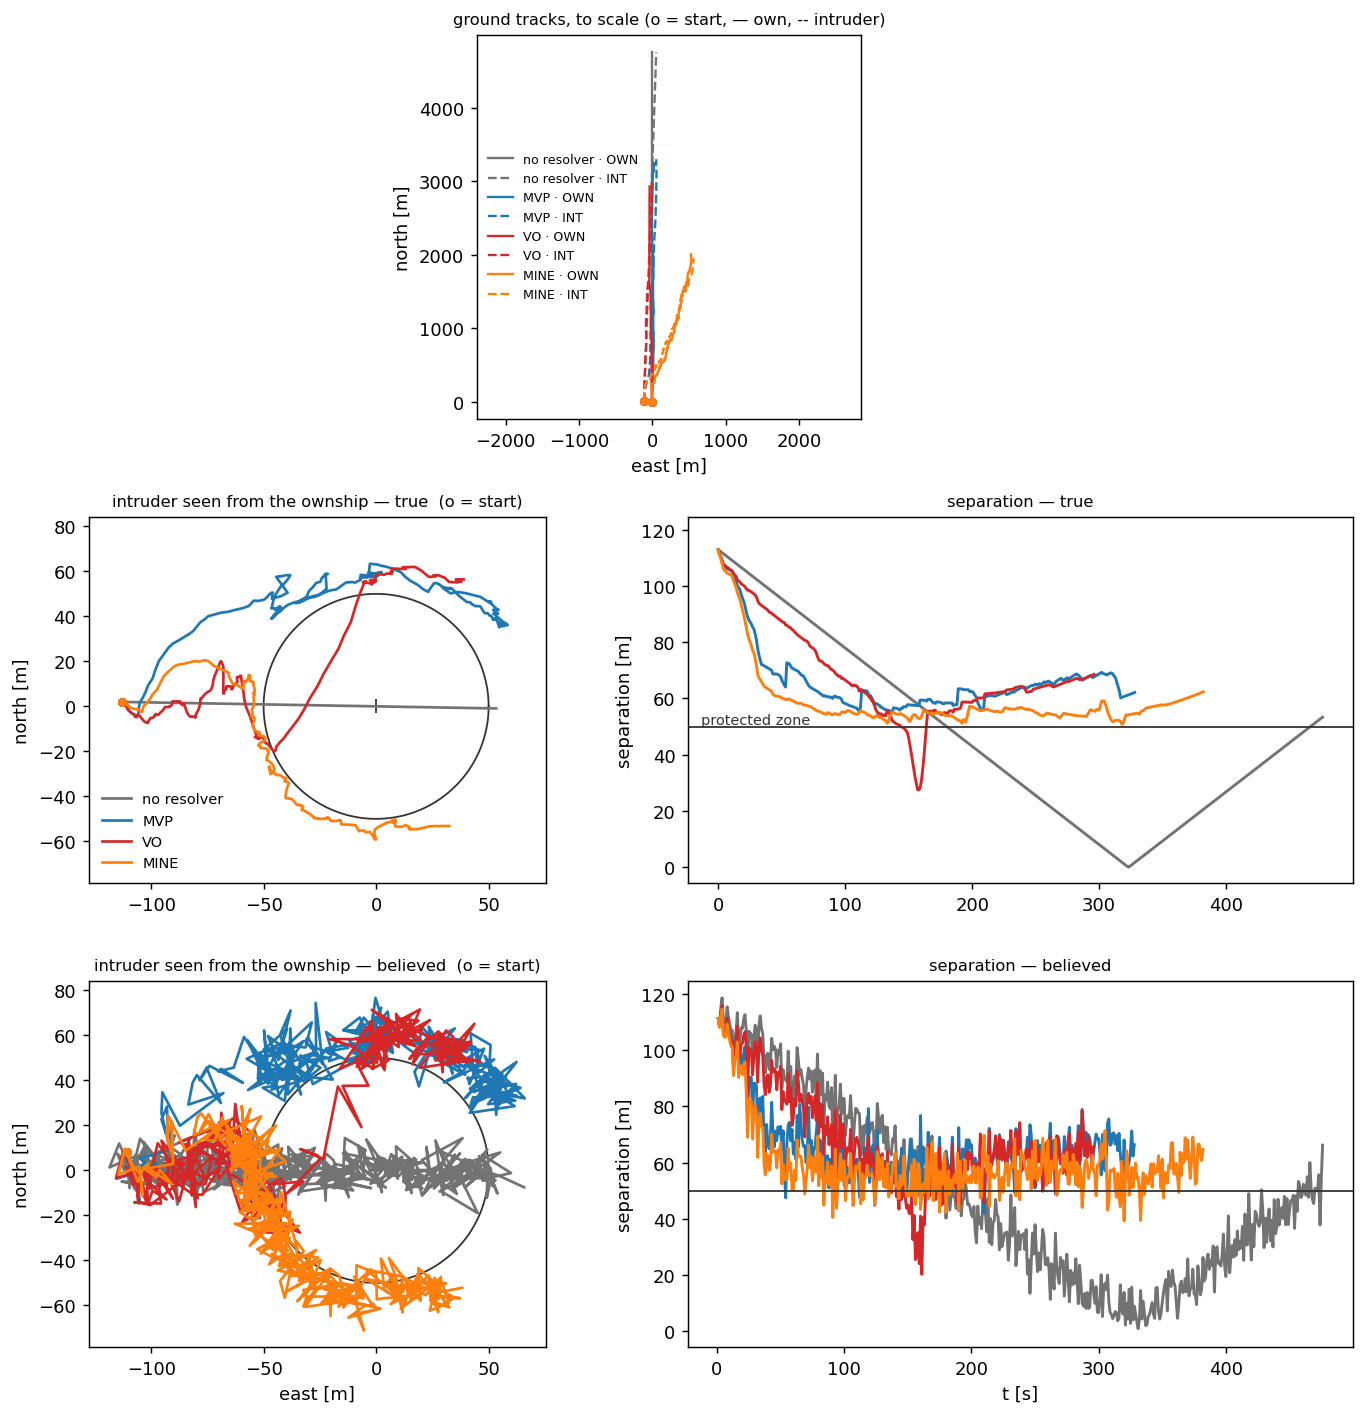

In [9]:
def relative_series(run, *, perceived: bool = False) -> tuple[np.ndarray, np.ndarray]:
    # the intruder relative to the ownship, per frame: the true geometry, or the believed one
    times, rel = [], []
    for f in run.frames:
        if perceived:
            own, intr = f.cns_state.last_tx        # each aircraft's own broadcast self-fix
            msg = f.cns_state.comm.held.get(("OWN", "INT"))
            intr = msg.state if msg is not None else intr   # a comm model routes it through held
            if own is None or intr is None:
                continue                           # t = 0: nobody has transmitted yet
        else:
            own, intr = f.states                   # ground truth — what min_sep is measured on
        r = relative_enu(own, intr)
        times.append(f.t)
        rel.append((r.rx, r.ry))
    return np.array(times), np.array(rel)


fig = plt.figure(figsize=(11.0, 11.0))
gs = fig.add_gridspec(3, 2, height_ratios=[1.05, 1.0, 1.0])
ax_gt = fig.add_subplot(gs[0, :])
axes = np.array([[fig.add_subplot(gs[r, c]) for c in (0, 1)] for r in (1, 2)])

for label, _, colour in CASES:
    t = extract_tracks(runs_2deg[label])
    for ac, track, style in zip(t.ids, t.tracks, ("-", "--")):
        ax_gt.plot(track[:, 0], track[:, 1], style, lw=1.3, color=colour,
                   label=f"{label} · {ac}")
        ax_gt.plot(track[0, 0], track[0, 1], marker="o", ms=4, color=colour)
ax_gt.set_xlabel("east [m]")
ax_gt.set_ylabel("north [m]")
ax_gt.set_aspect("equal", adjustable="datalim")   # 100 m east is 100 m north on the page
ax_gt.set_box_aspect(1)
ax_gt.set_title("ground tracks, to scale (o = start, — own, -- intruder)", fontsize=9)
ax_gt.legend(frameon=False, fontsize=7, loc="center left")

theta = np.linspace(0.0, 2.0 * np.pi, 200)

for row, perceived in enumerate((False, True)):
    ax_rel, ax_sep = axes[row]
    ax_rel.plot(RPZ * np.cos(theta), RPZ * np.sin(theta), color="0.2", lw=1.0)
    ax_rel.plot(0.0, 0.0, marker="+", ms=8, color="0.2")
    for label, _, colour in CASES:
        times, rel = relative_series(runs_2deg[label], perceived=perceived)
        ax_rel.plot(rel[:, 0], rel[:, 1], lw=1.5, color=colour, label=label)
        ax_rel.plot(rel[0, 0], rel[0, 1], marker="o", ms=4, color=colour)
        ax_sep.plot(times, np.hypot(rel[:, 0], rel[:, 1]), lw=1.6, color=colour, label=label)
    ax_sep.axhline(RPZ, color="0.2", lw=1.0)
    kind = "believed" if perceived else "true"
    ax_rel.set_ylabel("north [m]")
    ax_sep.set_ylabel("separation [m]")
    ax_rel.set_title(f"intruder seen from the ownship — {kind}  (o = start)", fontsize=9)
    ax_sep.set_title(f"separation — {kind}", fontsize=9)

# both rows on one scale, so the comparison is between the geometries and not between the axes
for col, pick in ((0, "xlim"), (0, "ylim"), (1, "ylim")):
    lo = min(getattr(a, f"get_{pick}")()[0] for a in axes[:, col])
    hi = max(getattr(a, f"get_{pick}")()[1] for a in axes[:, col])
    for a in axes[:, col]:
        getattr(a, f"set_{pick}")(lo, hi)
for a in axes[:, 0]:
    a.set_aspect("equal")

axes[1, 0].set_xlabel("east [m]")
axes[1, 1].set_xlabel("t [s]")
axes[0, 0].legend(frameon=False, fontsize=8, loc="best")
axes[0, 1].annotate("protected zone", (0.02, RPZ), xycoords=("axes fraction", "data"),
                    va="bottom", fontsize=8, color="0.2")
fig.tight_layout()
publish(fig, "exp-encounter")

In [10]:
print(f"{'':<12} {'true min [m]':>13} {'believed min [m]':>17} {'outcome.min_sep':>16}")
for label, _, _ in CASES:
    _, true_rel = relative_series(runs_2deg[label])
    _, seen_rel = relative_series(runs_2deg[label], perceived=True)
    print(f"{label:<12} {np.hypot(*true_rel.T).min():>13.2f} {np.hypot(*seen_rel.T).min():>17.2f}"
          f" {runs_2deg[label].min_sep:>16.2f}")

              true min [m]  believed min [m]  outcome.min_sep
no resolver           0.05              0.95             0.00
MVP                  54.92             41.91            54.92
VO                   27.44             20.28            27.33
MINE                 50.75             39.25            50.75


One encounter at 2°, `pos_ci95 = 10 m`, seed 0. The two relative-geometry rows share their scales,
so the comparison between them is between the geometries and not between the axes.

**Top, the ground tracks, drawn to scale** — 100 m east is 100 m north on the page. All eight
collapse into what looks like a single line, and that is not a plotting failure: at 2° the pair
flies close to five kilometres while the entire conflict, the manoeuvres and the protected zone are
a matter of tens of metres. Stretching the east axis would make the wandering visible, at the cost
of turning fifty metres of lateral correction into what reads as violent weaving.

This is why the two rows below use the **relative** frame. Subtracting the ownship's position
throws away the four kilometres both aircraft agree on and keeps the hundred metres they do not,
which is the encounter — and it works the same way at any crossing angle.

**Middle, the true relative geometry.** Left alone the pair converges to a direct hit, straight
through the circle. MVP clears it by five metres and `CloseRangeAvoid` by three quarters of one —
its turn fires at 70 m and only just works here. VO does not clear at all: it cuts to 27 m, well
inside the zone, which is a loss of separation.

**Bottom, the belief.** Same four runs, drawn from the self-fixes each aircraft actually
broadcast. It is visibly ragged because both fixes are redrawn independently every broadcast tick
(1 s here) and nothing filters them: `LastKnown` surveillance holds the newest message as-is, so
there is no smoothing anywhere in the chain. The relative vector carries *both* aircraft's errors,
so at `pos_ci95 = 10 m` each it jitters by tens of metres.

The table makes the gap concrete, and MVP's row is the one to look at: it believed it was **41.9 m**
from the intruder — inside the protected zone, a loss of separation — while the truth was 54.9 m
and it never breached at all. The resolver spent that encounter reacting to a conflict that was not
there. VO's belief ran the other way, 20.3 m against a true 27.4 m, and `CloseRangeAvoid` thought
it was at 39.3 m while flying 50.8 — which is the same 10 m-scale error, and enough to matter when
your rule triggers on a threshold.

**Which is why the score comes from the top row and the decisions come from the bottom one.** That
asymmetry is the entire subject of the sweep: `pos_ci95` widens the gap between the two rows, and
P(LoS) asks what the widening costs.

Two smaller things the table shows. `true min` is the minimum over sampled *frames*, while
`outcome.min_sep` closes the gaps between them — for VO it finds 27.33 m where the frames only saw
27.44 m, which is the segment-minimum measurement doing its job. And this stack has no
communication or surveillance model, so both aircraft read the same broadcast values and "the
ownship's view" is also the intruder's; add a directed comm model and the two beliefs diverge.

Do not read a verdict off one encounter. Change the seed and this flips: at seed 7 the same
geometry has VO clearing by three tenths of a metre. This is one of the 500 draws behind a single
point on the left-hand response curve, and a single run tells you what *can* happen, not how often.

For contrast, the same four runs at 30°.

In [11]:
runs_30deg = {label: one_encounter(30.0, r) for label, r, _ in CASES}
for label, run in runs_30deg.items():
    print(f"{label:<12} min_sep {run.min_sep:7.2f} m   LoS {str(run.los):<5}"
          f"  ended t = {run.frames[-1].t:.0f} s")

no resolver  min_sep    0.05 m   LoS True   ended t = 209 s
MVP          min_sep  181.96 m   LoS False  ended t = 145 s
VO           min_sep  181.93 m   LoS False  ended t = 145 s
MINE         min_sep  156.37 m   LoS False  ended t = 145 s


MVP and VO clear it by 182 m, within three centimetres of each other; `CloseRangeAvoid` clears by
156 m. All three finish at the same second. At 30° the geometry does most of the work — which is
the right-hand end of the response curves, seen from the inside. Note that this *particular* seed
clears for `CloseRangeAvoid` while 15% of the 500 at this angle do not: one encounter is an
anecdote, which is the whole reason the sweep exists.

## Reproducibility

Every number above is a function of the base config, the declared levels, the seed, and the library
code — nothing else. `card_dir` writes that down as a Markdown card beside the results, using the
same component identity strings the cache keys on, so a card and a cache entry cannot disagree
about what was run.

The `assert` below is not decoration. A cache may only ever save time; it must never change a
result, and that promise is only worth having if something checks it. This one caught a real
collision while the notebook was being written — every level of the resolver sweep shared a cache
key, so VO was served MVP's numbers under its own name, and the table looked entirely plausible.
Keep an assertion like this in any sweep you cache.

In [12]:
carded = run_experiment(
    {"dpsi": Sweep(ANGLES),
     "resolver": Sweep(list(RESOLVERS), build=RESOLVERS.__getitem__, name="resolver"),
     "pos_ci95": Sweep(NOISE),
     "vel_ci95": Fixed(1.0), "dcpa": Fixed(0.0), "tlos": Fixed(TLOS), "speed": Fixed(SPEED)},
    methods=methods,
    backend=MC(n_encounters=500),
    base_config=base,
    seed=SEED,
    cache=True,
    card_dir=Path(tempfile.mkdtemp()),   # a real run would keep this beside the results
)

assert carded.records() == sweep.records()   # served from cache, identical numbers
print("\n".join(carded.card_path.read_text().splitlines()[:16]))

# Experiment 20260731T134357_242461Z

- backend: `MC(n_encounters=500)`
- seed: 0
- conditions: 24
- swept axes: ['dpsi', 'resolver', 'pos_ci95']
- code_hash: 68298af27747a729

## Declaration

- `dpsi`: Sweep([2.0, 5.0, 10.0, 30.0])
- `resolver`: Sweep(['MVP', 'VO', 'MINE']) as `resolver` via build()
- `pos_ci95`: Sweep([10.0, 30.0])
- `vel_ci95`: Fixed(1.0)
- `dcpa`: Fixed(0.0)
- `tlos`: Fixed(180.0)


## Where to take it next

- **Sweep the margin.** `Sweep([1.05, 1.2, 1.5], build=lambda m: MVP(margin=m), name="margin")`
  puts the number in the table and the object in the run. The median is the metric that will show
  what a wider resolution zone buys, since P(LoS) is already at zero for most of this grid.
- **Go rarer.** At 30° both library resolvers sit at 0 LoS in 500 encounters, so plain Monte Carlo has
  nothing left to measure. Swapping `backend=MC(...)` for
  `backend=IPS(shells=[...], n_particles=..., reps=...)` estimates the same quantity by splitting,
  and the rest of the declaration is unchanged. Note that `median_min_sep` is deliberately absent
  on that backend: splitting discards the particles that miss a shell and clones the survivors, so
  its cloud samples the rare set rather than the encounter population, and a median over it would
  be a median given near-LoS wearing the wrong label.
- **Degrade something else.** `communication=` takes a lossy channel or a `TransceiverComm` whose
  radios fail and recover, and both are declarable as axes the same way.
- **Improve on `CloseRangeAvoid`.** It is deliberately naive: a fixed trigger, a fixed turn, no use
  of `rpz`, closing speed or the `preferred` velocity it is handed. Giving it any one of those
  should bend its flat curve down at wide angles — and the sweep above is the test, unchanged.
- **Bring another one.** Subclass `ConflictResolver`, add it to the `RESOLVERS` dict, and every cell
  above runs against it — see `02_build_your_own_separation_manager.ipynb` for the interface in
  full.